# Phase 6 — Linear Regression (OLS)

Unregularised least squares on log-rent: the reference point for every other model.

This notebook does **no data cleaning**. It:
1. loads the frozen Phase-5 bundle `prepared_data.joblib` (upload it into the Colab working directory);
2. **verifies the fingerprint** and stops on any mismatch;
3. builds `TransformedTargetRegressor(Pipeline([StandardScaler, model]), log1p, expm1)` (the scaler is fit on X_train only and re-fit in every CV fold);
4. trains on X_train, then reports **train / validation** metrics and **5-fold CV RMSE on train**, all in ₹;
5. evaluates the test set **only if `EVALUATE_TEST = True`** (Phase 9);
6. saves predictions and metrics to `outputs/`, then plots.

Only the model cell differs between the Phase-6 notebooks.

In [1]:
# No extra packages needed: scikit-learn, pandas, numpy, matplotlib and joblib are preinstalled in Colab.

In [2]:
import os, json, time, hashlib, warnings
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.linear_model import LinearRegression

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
EVALUATE_TEST = False                      # stays False until Phase 9
EXPECTED_REFERENCE_ID = "70560d1bd70af7cd"         # from phase5_prepare_data.ipynb
MODEL_NAME = "Linear Regression"
MODEL_KEY = "linear_regression"
CV_FOLDS = 5
os.makedirs("outputs", exist_ok=True)

In [3]:
d = joblib.load("prepared_data.joblib")       # numpy arrays + builtins only → loads under any pandas version
if not str(d.get("storage_format", "")).startswith("numpy-v1") or not isinstance(d["X_train"], np.ndarray):
    raise RuntimeError("BUNDLE / NOTEBOOK VERSION MISMATCH — STOP. This notebook expects the numpy-format bundle "
                       "(storage_format 'numpy-v1') written by the current phase5_prepare_data.ipynb. "
                       "Re-upload BOTH the latest prepared_data.joblib and the latest copy of this notebook.")
feature_names = list(d["feature_names"])

def frames_from_bundle(d):
    # Rebuild DataFrames/Series: float64 X, int64 y in rupees, original row ids as index (identical to Phase 5)
    out = {}
    for s in ("train", "val", "test"):
        idx = pd.Index(d[f"index_{s}"], dtype="int64")
        out[f"X_{s}"] = pd.DataFrame(d[f"X_{s}"], columns=feature_names, index=idx)
        out[f"y_{s}"] = pd.Series(d[f"y_{s}"], index=idx, name="Rent")
    return out

f = frames_from_bundle(d)
X_train, X_val, X_test = f["X_train"], f["X_val"], f["X_test"]
y_train, y_val, y_test = f["y_train"], f["y_val"], f["y_test"]
print("Loaded:", X_train.shape, X_val.shape, X_test.shape, "| target_transform:", d["target_transform"])

Loaded: (3313, 34) (711, 34) (711, 34) | target_transform: log1p


In [4]:
def _h(b):
    return hashlib.sha256(b).hexdigest()[:16]

def compute_fingerprint(X_train, X_val, X_test, y_train, y_val, y_test, feature_names):
    splits = {"train": (X_train, y_train), "val": (X_val, y_val), "test": (X_test, y_test)}
    ref = {"n_rows": {k: int(len(x)) for k, (x, _) in splits.items()},
           "n_features": len(feature_names),
           "feature_names_hash": _h("|".join(feature_names).encode()),
           "index_hash_sorted": {k: _h(np.sort(x.index.to_numpy("int64")).tobytes()) for k, (x, _) in splits.items()},
           "index_hash_ordered": {k: _h(x.index.to_numpy("int64").tobytes()) for k, (x, _) in splits.items()},
           "target_hash": {k: _h(y.to_numpy("int64").tobytes()) for k, (_, y) in splits.items()}}
    ref["reference_id"] = _h(json.dumps(ref, sort_keys=True).encode())
    content = {k: _h(np.ascontiguousarray(x.to_numpy("float64")).tobytes()) for k, (x, _) in splits.items()}
    return {"reference": ref, "content": content}

fp = compute_fingerprint(X_train, X_val, X_test, y_train, y_val, y_test, feature_names)
problems = []
if fp["reference"]["reference_id"] != EXPECTED_REFERENCE_ID:
    problems.append(f"reference_id {fp['reference']['reference_id']} != expected {EXPECTED_REFERENCE_ID}")
if fp["reference"] != d["fingerprint"]["reference"]:
    problems.append("reference fingerprint differs from the bundle's record")
if fp["content"] != d["fingerprint"]["content"]:
    problems.append("X content hash differs from the bundle's record")
if list(X_train.columns) != feature_names or list(X_val.columns) != feature_names or list(X_test.columns) != feature_names:
    problems.append("column order != feature_names")
if d["target_transform"] not in ("log1p", "none"):
    problems.append(f"unknown target_transform {d['target_transform']!r}")
if problems:
    raise RuntimeError("FINGERPRINT MISMATCH — STOP. Do not train.\n  " + "\n  ".join(problems))
print(f"Dataset:  Rows: {len(X_train) + len(X_val) + len(X_test)}  Features: {len(feature_names)}   Fingerprint: OK ({EXPECTED_REFERENCE_ID})")

Dataset:  Rows: 4735  Features: 34   Fingerprint: OK (70560d1bd70af7cd)


In [5]:
# ---- the only model-specific cell ----
estimator = LinearRegression()
steps = [("scaler", StandardScaler()), ("model", estimator)]   # scaler fit on X_train only (re-fit per CV fold)
pipe = Pipeline(steps)
if d["target_transform"] == "log1p":
    model = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)   # predictions in ₹
else:
    model = pipe
model

,"regressor regressor: object, default=NoneRegressor object such as derived from:class:`~sklearn.base.RegressorMixin`. This regressor willautomatically be cloned each time prior to fitting. If `regressor isNone`, :class:`~sklearn.linear_model.LinearRegression` is created and used.",Pipeline(step...egression())])
,"transformer transformer: object, default=NoneEstimator object such as derived from:class:`~sklearn.base.TransformerMixin`. Cannot be set at the same timeas `func` and `inverse_func`. If `transformer is None` as well as`func` and `inverse_func`, the transformer will be an identitytransformer. Note that the transformer will be cloned during fitting.Also, the transformer is restricting `y` to be a numpy array.",None
,"func func: function, default=NoneFunction to apply to `y` before passing to :meth:`fit`. Cannot be setat the same time as `transformer`. If `func is None`, the function used will bethe identity function. If `func` is set, `inverse_func` also needs to beprovided. The function needs to return a 2-dimensional array.",<ufunc 'log1p'>
,"inverse_func inverse_func: function, default=NoneFunction to apply to the prediction of the regressor. Cannot be set atthe same time as `transformer`. The inverse function is used to returnpredictions to the same space of the original training labels. If`inverse_func` is set, `func` also needs to be provided. The inversefunction needs to return a 2-dimensional array.",<ufunc 'expm1'>
,"check_inverse check_inverse: bool, default=TrueWhether to check that `transform` followed by `inverse_transform`or `func` followed by `inverse_func` leads to the original targets.",True
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


In [6]:
t0 = time.perf_counter()
model.fit(X_train, y_train)
train_time = time.perf_counter() - t0
print(f"Training time: {train_time:.2f} s")

Training time: 0.02 s


In [7]:
def metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {"MAE": mean_absolute_error(y_true, y_pred), "MSE": mse, "RMSE": float(np.sqrt(mse)), "R2": r2_score(y_true, y_pred)}

pred = {"train": model.predict(X_train), "val": model.predict(X_val)}
results = {"train": metrics(y_train, pred["train"]), "val": metrics(y_val, pred["val"])}

# 5-fold CV on TRAIN only; the whole pipeline (scaler + target transform) is cloned and re-fit in each fold
cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
scoring = {"rmse": make_scorer(lambda a, p: np.sqrt(mean_squared_error(a, p)), greater_is_better=False),
           "mae": make_scorer(mean_absolute_error, greater_is_better=False), "r2": "r2"}
t0 = time.perf_counter()
cvr = cross_validate(clone(model), X_train, y_train, cv=cv, scoring=scoring)
cv_time = time.perf_counter() - t0
cv_rmse_folds = -cvr["test_rmse"]
results["cv"] = {"RMSE_mean": float(cv_rmse_folds.mean()), "RMSE_std": float(cv_rmse_folds.std()),
                 "MAE_mean": float(-cvr["test_mae"].mean()), "R2_mean": float(cvr["test_r2"].mean()),
                 "fold_RMSE": cv_rmse_folds.round(1).tolist(), "time_s": cv_time}
print("CV RMSE per fold (₹):", cv_rmse_folds.round(0).tolist())

CV RMSE per fold (₹): [29552.0, 27881.0, 25291.0, 43244.0, 24313.0]


In [8]:
if EVALUATE_TEST:
    pred["test"] = model.predict(X_test)
    results["test"] = metrics(y_test, pred["test"])
    print("Test set evaluated.")
else:
    print("EVALUATE_TEST = False → test set untouched (Phase 9 only).")

EVALUATE_TEST = False → test set untouched (Phase 9 only).


In [9]:
splits = [s for s in ("train", "val", "test") if s in results]
table = pd.DataFrame({s: results[s] for s in splits}).T[["MAE", "MSE", "RMSE", "R2"]]
table["CV RMSE"] = results["cv"]["RMSE_mean"]
table["Training time (s)"] = train_time
display(table.style.format({"MAE": "₹{:,.0f}", "MSE": "{:.4g}", "RMSE": "₹{:,.0f}", "R2": "{:.4f}",
                            "CV RMSE": "₹{:,.0f}", "Training time (s)": "{:.2f}"}))

r = results
print("=" * 40); print(f"MODEL: {MODEL_NAME}"); print("=" * 40)
print(f"Dataset:  Rows: {len(X_train) + len(X_val) + len(X_test)}  Features: {len(feature_names)}   Fingerprint: OK")
line = f"Train RMSE: {r['train']['RMSE']:,.2f}   Validation RMSE: {r['val']['RMSE']:,.2f}"
if "test" in r:
    line += f"   Test RMSE: {r['test']['RMSE']:,.2f}"
print(line)
for s in splits[1:]:
    lab = "Validation" if s == "val" else "Test"
    print(f"{lab} MAE: {r[s]['MAE']:,.2f}   {lab} MSE: {r[s]['MSE']:,.2f}   {lab} R²: {r[s]['R2']:.4f}")
print(f"CV RMSE: {r['cv']['RMSE_mean']:,.2f} (± {r['cv']['RMSE_std']:,.2f}, {CV_FOLDS}-fold on train)")
print(f"Training Time: {train_time:.2f} s   (CV time: {r['cv']['time_s']:.2f} s)")

with open(f"outputs/metrics_{MODEL_KEY}.json", "w") as f:
    json.dump({"model": MODEL_NAME, "key": MODEL_KEY, "reference_id": EXPECTED_REFERENCE_ID, "evaluate_test": EVALUATE_TEST,
               "train_time_s": train_time, **results}, f, indent=2)

,MAE,MSE,RMSE,R2,CV RMSE,Training time (s)
train,"₹10,503",9.025e+08,"₹30,041",0.7310,"₹30,056",0.02
val,"₹13,596",2.687e+09,"₹51,834",0.4879,"₹30,056",0.02


MODEL: Linear Regression
Dataset:  Rows: 4735  Features: 34   Fingerprint: OK
Train RMSE: 30,040.92   Validation RMSE: 51,834.12
Validation MAE: 13,595.82   Validation MSE: 2,686,776,336.21   Validation R²: 0.4879
CV RMSE: 30,056.25 (± 6,849.86, 5-fold on train)
Training Time: 0.02 s   (CV time: 0.03 s)


In [10]:
pred_df = pd.concat([pd.DataFrame({"row_id": Xs.index, "split": s, "actual_rent": ys.to_numpy(),
                                   "predicted_rent": pred[s], "residual": ys.to_numpy() - pred[s]})
                     for s, Xs, ys in (("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)) if s in pred])
pred_df.to_csv(f"outputs/predictions_{MODEL_KEY}.csv", index=False)
print(f"Saved outputs/predictions_{MODEL_KEY}.csv:", pred_df.shape)
display(pred_df.head())

Saved outputs/predictions_linear_regression.csv: (4024, 5)


,row_id,split,actual_rent,predicted_rent,residual
0,1124,train,95000,68744.793993,26255.206007
1,3886,train,12000,25208.045915,-13208.045915
2,4122,train,14000,13699.037163,300.962837
3,2762,train,6500,10394.774155,-3894.774155
4,1963,train,30000,22307.136059,7692.863941


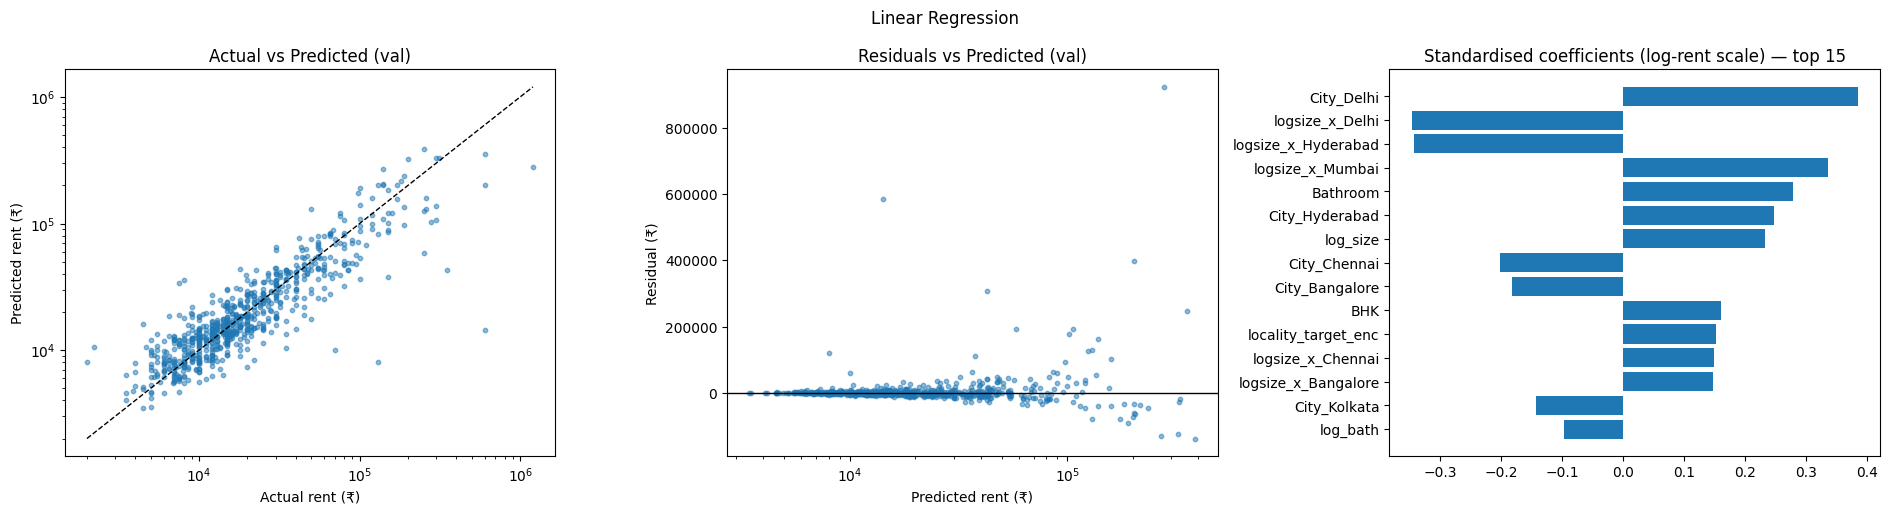

Non-zero coefficients: 34 / 34


In [11]:
inner = (model.regressor_ if hasattr(model, "regressor_") else model).named_steps["model"]
if hasattr(inner, "coef_"):
    imp = pd.Series(np.ravel(inner.coef_), index=feature_names); imp_title = "Standardised coefficients (log-rent scale)"
elif hasattr(inner, "feature_importances_"):
    imp = pd.Series(inner.feature_importances_, index=feature_names); imp_title = "Feature importances"
else:
    imp = None

s = "test" if "test" in pred else "val"
yt, yp = (y_test if s == "test" else y_val).to_numpy(), pred[s]
fig, ax = plt.subplots(1, 3, figsize=(19, 5.2))
ax[0].scatter(yt, yp, s=10, alpha=.5); lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
ax[0].plot(lim, lim, "k--", lw=1); ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("Actual rent (₹)"); ax[0].set_ylabel("Predicted rent (₹)"); ax[0].set_title(f"Actual vs Predicted ({s})")
ax[1].scatter(yp, yt - yp, s=10, alpha=.5); ax[1].axhline(0, color="k", lw=1); ax[1].set_xscale("log")
ax[1].set_xlabel("Predicted rent (₹)"); ax[1].set_ylabel("Residual (₹)"); ax[1].set_title(f"Residuals vs Predicted ({s})")
if imp is not None and np.any(imp != 0):
    top = imp.reindex(imp.abs().sort_values(ascending=False).index)[:15][::-1]
    ax[2].barh(top.index, top.values); ax[2].set_title(imp_title + " — top 15")
else:
    ax[2].text(.5, .5, "all coefficients are 0" if imp is not None else "n/a", ha="center"); ax[2].set_axis_off()
fig.suptitle(MODEL_NAME); plt.tight_layout(); plt.show()
if imp is not None and hasattr(inner, "coef_"):
    print(f"Non-zero coefficients: {(np.abs(imp) > 0).sum()} / {len(imp)}")

## Results summary (baseline run, `EVALUATE_TEST = False`)

| | MAE (₹) | MSE | RMSE (₹) | R² |
|---|---|---|---|---|
| Train | 10,503 | 9.025e+08 | 30,041 | 0.7310 |
| Validation | 13,596 | 2.687e+09 | 51,834 | 0.4879 |

**CV RMSE (5-fold, train):** ₹30,056 ± 6,850 · CV MAE ₹10,676 · CV R² 0.7286 · **Training time:** 0.02 s

Train RMSE ≈ CV RMSE, so there is **no overfitting**. The model is high-bias but stable. The validation gap comes from the extreme tail (see below).

**Validation RMSE vs CV RMSE:** validation RMSE sits well above CV RMSE for every Phase-6 model. A single validation row (a genuine ₹12,00,000, 5,000 sqft, 4 BHK Mumbai listing) carries about 45% of the validation squared error, and the top two rows carry about 69%. Validation rows are never removed (CLAUDE.md), so read RMSE together with MAE and R².
